## Task 1: Install required Python libraries

In [1]:
%pip install -q pandas numpy scikit-learn matplotlib streamlit joblib requests

import pandas as pd
import numpy as np
import sklearn
import matplotlib
import streamlit
import joblib
import requests

print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"matplotlib:   {matplotlib.__version__}")
print(f"streamlit:    {streamlit.__version__}")
print(f"joblib:       {joblib.__version__}")
print(f"requests:     {requests.__version__}")

You should consider upgrading via the 'c:\users\lenovo\appdata\local\programs\python\python38\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.
pandas:       2.0.3
numpy:        1.24.4
scikit-learn: 1.3.2
matplotlib:   3.7.5
streamlit:    1.40.1
joblib:       1.4.2
requests:     2.32.4


## Task 2: Download the dataset

In [2]:
from pathlib import Path
import requests
import pandas as pd

data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

csv_path = data_dir / "space_weather_unified.csv"

if csv_path.exists():
    print(f"Using cached {csv_path}")
else:
    print("File not found locally. Please ensure space_weather_unified.csv is in the data/ folder.")

matches = pd.read_csv(csv_path, parse_dates=["date"])
print(f"Shape: {matches.shape}")
print(f"Date range: {matches['date'].min().date()} \u2192 {matches['date'].max().date()}")
matches.head(3)

Using cached data\space_weather_unified.csv
Shape: (1743, 18)
Date range: 2023-07-11 → 2025-07-09


,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,14
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2023-07-11,2023,7,11,16


## Task 3: Prepare the data

In [3]:
import pandas as pd
import numpy as np

# Load the dataset
space_df = pd.read_csv('data/space_weather_unified.csv')

print("=== Initial Data Info ===")
print(f"Shape: {space_df.shape}")
print("\nColumns and Data Types:")
print(space_df.dtypes.to_string())
print("\nFirst 3 rows:")
print(space_df.head(3).to_string())

print("\n=== Missing Values Analysis ===")
missing_counts = space_df.isnull().sum()
missing_pct = (missing_counts / len(space_df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing_Count': missing_counts,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df.to_string())

print("\n=== Data Cleaning ===")
initial_rows = len(space_df)

# Handle missing values
space_df['kp_index']        = space_df['kp_index'].fillna(0.0)
space_df['class_type']      = space_df['class_type'].fillna('Unknown')
space_df['source_location'] = space_df['source_location'].fillna('Unknown')
space_df['active_region']   = space_df['active_region'].fillna('Unknown')
space_df['note']            = space_df['note'].fillna('')

# Remove duplicates
duplicates_count = space_df.duplicated(subset=['event_id']).sum()
space_df = space_df.drop_duplicates(subset=['event_id'], keep='first')

# Convert datetime columns
for col in ['begin_time', 'peak_time', 'end_time', 'observed_time']:
    space_df[col] = pd.to_datetime(space_df[col], errors='coerce')

# Overwrite year, month, hour from begin_time
space_df['year']  = space_df['begin_time'].dt.year.fillna(0).astype(int)
space_df['month'] = space_df['begin_time'].dt.month.fillna(0).astype(int)
space_df['hour']  = space_df['begin_time'].dt.hour.fillna(0).astype(int)

# Calculate duration in minutes
space_df['duration_minutes'] = (
    (space_df['end_time'] - space_df['begin_time']).dt.total_seconds() / 60
).fillna(0.0)

# Extract flare magnitude and class
def extract_flare_info(row):
    if row['event_type'] == 'Solar Flare' and pd.notna(row['class_type']) and row['class_type'] != 'Unknown':
        class_str = str(row['class_type'])
        flare_class = class_str[0] if class_str else 'N/A'
        try:
            magnitude_str = ''.join(c for c in class_str if c.isdigit() or c == '.')
            magnitude = float(magnitude_str) if magnitude_str else 0.0
        except:
            magnitude = 0.0
        return pd.Series({'flare_magnitude': magnitude, 'flare_class': flare_class})
    return pd.Series({'flare_magnitude': 0.0, 'flare_class': 'N/A'})

space_df[['flare_magnitude', 'flare_class']] = space_df.apply(extract_flare_info, axis=1)

final_rows = len(space_df)

print(f"Initial rows:       {initial_rows:,}")
print(f"Duplicates removed: {duplicates_count:,}")
print(f"Final rows:         {final_rows:,}")

print("\nRemaining missing values:")
remaining_missing = space_df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(remaining_missing.to_string())
else:
    print("No missing values in key columns (kp_index, class_type, source_location, active_region, note)")

print("\n=== First 3 Rows After Cleaning ===")
space_df.head(3)

=== Initial Data Info ===
Shape: (1743, 18)

Columns and Data Types:
event_id            object
event_type          object
begin_time          object
peak_time           object
end_time            object
class_type          object
source_location     object
active_region      float64
instruments         object
note                object
kp_index           float64
observed_time       object
source              object
date                object
year                 int64
month                int64
day                  int64
hour                 int64

First 3 rows:
                      event_id   event_type                 begin_time                  peak_time                   end_time class_type source_location  active_region           instruments note  kp_index observed_time source        date  year  month  day  hour
0  2023-07-11T14:19:00-FLR-001  Solar Flare  2023-07-11 14:19:00+00:00  2023-07-11 14:35:00+00:00  2023-07-11 14:45:00+00:00       M2.0          N25E90        13379.0  G

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,...,observed_time,source,date,year,month,day,hour,duration_minutes,flare_magnitude,flare_class
0,2023-07-11T14:19:00-FLR-001,Solar Flare,2023-07-11 14:19:00+00:00,2023-07-11 14:35:00+00:00,2023-07-11 14:45:00+00:00,M2.0,N25E90,13379.0,GOES-P: EXIS 1.0-8.0,,...,NaT,NaN,2023-07-11,2023,7,11,14,26.0,2.0,M
1,2023-07-11T16:02:00-FLR-001,Solar Flare,2023-07-11 16:02:00+00:00,2023-07-11 16:12:00+00:00,2023-07-11 16:25:00+00:00,M1.1,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,,...,NaT,NaN,2023-07-11,2023,7,11,16,23.0,1.1,M
2,2023-07-11T16:25:00-FLR-001,Solar Flare,2023-07-11 16:25:00+00:00,2023-07-11 16:27:00+00:00,2023-07-11 16:30:00+00:00,M1.0,N25E89,13372.0,GOES-P: EXIS 1.0-8.0,,...,NaT,NaN,2023-07-11,2023,7,11,16,5.0,1.0,M


## Task 4: Explore and analyze the data

Matplotlib is building the font cache; this may take a moment.


=== 1. Event Type Distribution ===
                   Count  Percentage
event_type                          
Solar Flare         1599       91.74
High Speed Stream    103        5.91
Geomagnetic Storm     41        2.35

=== 2. Temporal Summary ===
Events per Year:
year
2023     247
2024    1181
2025     315

Events per Month:
month
1     118
2     135
3     118
4     119
5     234
6     104
7     167
8     196
9     140
10    132
11    133
12    147

Events per Hour:
hour
0     74
1     64
2     68
3     84
4     73
5     69
6     78
7     64
8     79
9     73
10    62
11    71
12    92
13    65
14    69
15    76
16    70
17    62
18    69
19    78
20    75
21    81
22    76
23    71

=== 3. Solar Flare Summary ===
Total Solar Flares: 1,599

Flare Class Distribution:
flare_class
M    1329
C     201
X      68
B       1

Flare Magnitude — Mean: 2.64, Median: 1.70, Min: 1.00, Max: 9.90
Duration (min)   — Mean: 26.54, Median: 20.00, Min: 3.00, Max: 291.00

=== 4. Geomagnetic Storm Summary

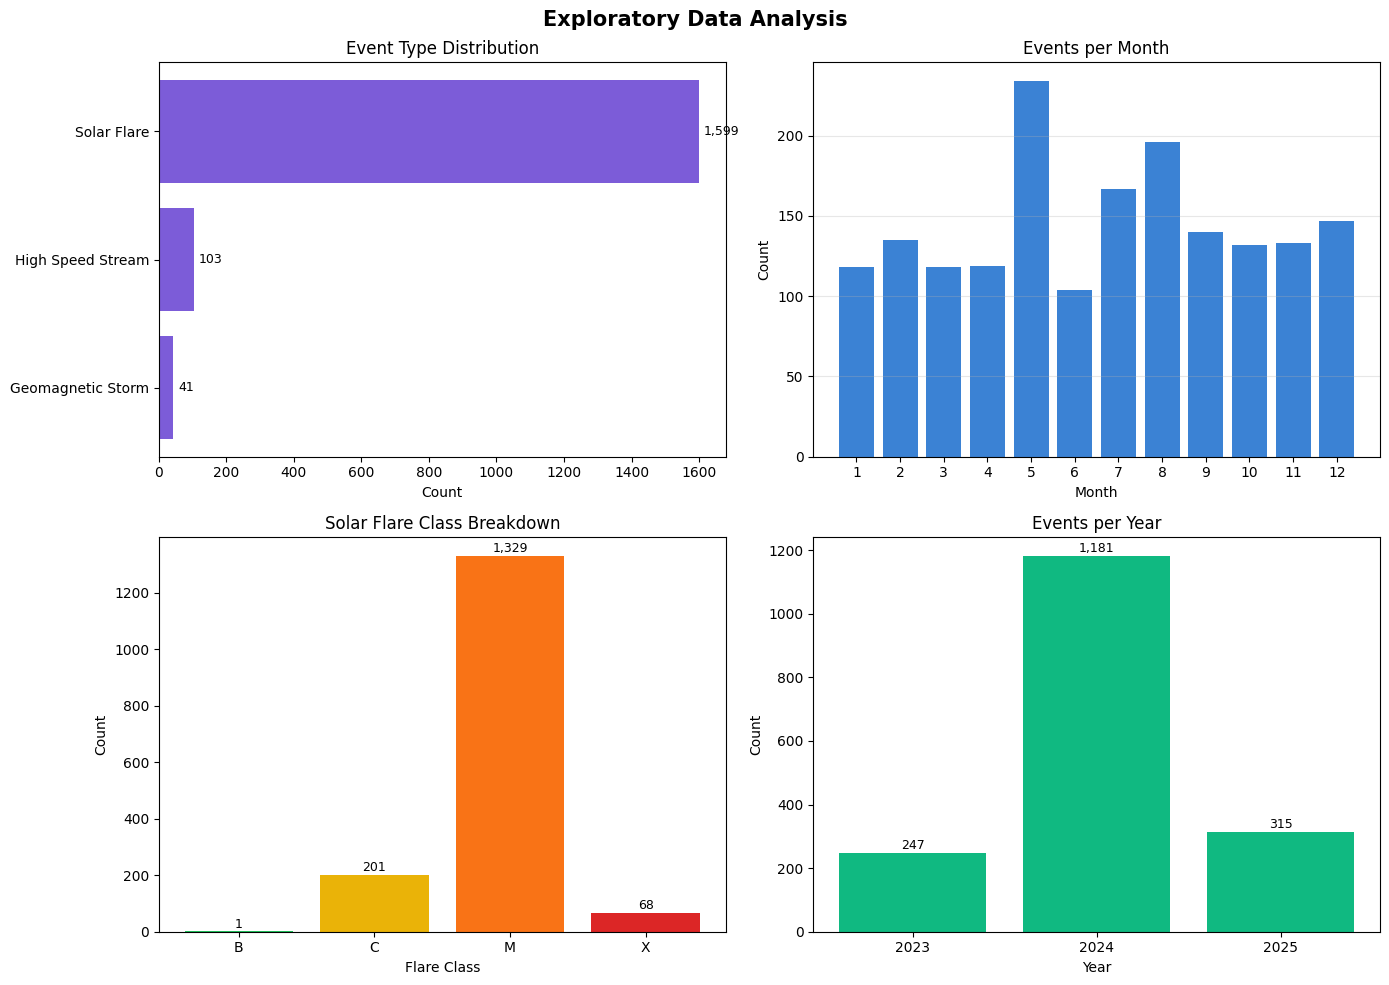

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === PART A: STATISTICS ===

print("=== 1. Event Type Distribution ===")
event_dist = space_df['event_type'].value_counts()
event_pct = (event_dist / len(space_df) * 100).round(2)
print(pd.DataFrame({'Count': event_dist, 'Percentage': event_pct}).to_string())

print("\n=== 2. Temporal Summary ===")
print("Events per Year:")
print(space_df['year'].value_counts().sort_index().to_string())
print("\nEvents per Month:")
print(space_df['month'].value_counts().sort_index().to_string())
print("\nEvents per Hour:")
print(space_df['hour'].value_counts().sort_index().to_string())

print("\n=== 3. Solar Flare Summary ===")
solar_flares = space_df[space_df['event_type'] == 'Solar Flare']
print(f"Total Solar Flares: {len(solar_flares):,}")
print("\nFlare Class Distribution:")
print(solar_flares['flare_class'].value_counts().to_string())
flare_mag = solar_flares[solar_flares['flare_magnitude'] > 0]['flare_magnitude']
print(f"\nFlare Magnitude \u2014 Mean: {flare_mag.mean():.2f}, Median: {flare_mag.median():.2f}, Min: {flare_mag.min():.2f}, Max: {flare_mag.max():.2f}")
flare_dur = solar_flares[solar_flares['duration_minutes'] > 0]['duration_minutes']
print(f"Duration (min)   \u2014 Mean: {flare_dur.mean():.2f}, Median: {flare_dur.median():.2f}, Min: {flare_dur.min():.2f}, Max: {flare_dur.max():.2f}")

print("\n=== 4. Geomagnetic Storm Summary ===")
geo_storms = space_df[space_df['event_type'] == 'Geomagnetic Storm']
print(f"Total Geomagnetic Storms: {len(geo_storms):,}")
print("\nStorm Class Distribution:")
print(geo_storms['class_type'].value_counts().to_string())
kp_values = geo_storms[geo_storms['kp_index'] > 0]['kp_index']
if len(kp_values) > 0:
    print(f"\nKp Index \u2014 Mean: {kp_values.mean():.2f}, Median: {kp_values.median():.2f}, Min: {kp_values.min():.2f}, Max: {kp_values.max():.2f}")
else:
    print("No Kp index data available")

# === PART B: CHARTS ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')

# Subplot 1: Event Type Distribution
ax1 = axes[0, 0]
et_counts = space_df['event_type'].value_counts().sort_values(ascending=True)
bars1 = ax1.barh(et_counts.index, et_counts.values, color='#7c5cd8')
for bar, val in zip(bars1, et_counts.values):
    ax1.text(bar.get_width() + et_counts.values.max() * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_title('Event Type Distribution')
ax1.set_xlabel('Count')

# Subplot 2: Events per Month
ax2 = axes[0, 1]
monthly = space_df['month'].value_counts().sort_index()
ax2.bar(monthly.index, monthly.values, color='#3b82d4')
ax2.set_xticks(range(1, 13))
ax2.yaxis.grid(True, alpha=0.3)
ax2.set_title('Events per Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Count')

# Subplot 3: Solar Flare Class Breakdown
ax3 = axes[1, 0]
flare_df = space_df[(space_df['event_type'] == 'Solar Flare') & (space_df['flare_class'] != 'N/A')]
fc_counts = flare_df['flare_class'].value_counts().sort_index()
class_colors = {'X': '#dc2626', 'M': '#f97316', 'C': '#eab308', 'B': '#22c55e'}
colors3 = [class_colors.get(c, '#94a3b8') for c in fc_counts.index]
bars3 = ax3.bar(fc_counts.index, fc_counts.values, color=colors3)
for bar, val in zip(bars3, fc_counts.values):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + fc_counts.values.max() * 0.01,
             f'{val:,}', ha='center', fontsize=9)
ax3.set_title('Solar Flare Class Breakdown')
ax3.set_xlabel('Flare Class')
ax3.set_ylabel('Count')

# Subplot 4: Events per Year
ax4 = axes[1, 1]
yearly = space_df['year'].value_counts().sort_index()
bars4 = ax4.bar(yearly.index.astype(str), yearly.values, color='#10b981')
for bar, val in zip(bars4, yearly.values):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + yearly.values.max() * 0.01,
             f'{val:,}', ha='center', fontsize=9)
ax4.set_title('Events per Year')
ax4.set_xlabel('Year')
ax4.set_ylabel('Count')

plt.tight_layout()
plt.show()

## Task 5: Add feature engineering for risk assessment

In [5]:
import pandas as pd
from datetime import timedelta

# Step 1 — Filter and sort from 2023 onward
sw = space_df[space_df['date'] >= '2023-01-01'].sort_values('date').reset_index(drop=True)
sw['date'] = pd.to_datetime(sw['date'])

# Step 2 — Compute risk features per unique date
unique_dates = sw['date'].unique()
rows = []

for current_date in unique_dates:
    window_start = current_date - timedelta(hours=48)
    window_data = sw[(sw['date'] >= window_start) & (sw['date'] < current_date)]

    xclass = len(window_data[(window_data['event_type'] == 'Solar Flare') & (window_data['flare_class'] == 'X')])
    mclass = len(window_data[(window_data['event_type'] == 'Solar Flare') & (window_data['flare_class'] == 'M')])
    cclass = len(window_data[(window_data['event_type'] == 'Solar Flare') & (window_data['flare_class'] == 'C')])

    kp_values = window_data['kp_index'].dropna()
    max_kp = kp_values.max() if len(kp_values) > 0 else 0
    avg_kp = kp_values.mean() if len(kp_values) > 0 else 0

    storm_count = len(window_data[window_data['kp_index'] >= 5])

    last_24h = sw[(sw['date'] >= current_date - timedelta(hours=24)) & (sw['date'] < current_date)]
    prev_24h = sw[(sw['date'] >= current_date - timedelta(hours=48)) & (sw['date'] < current_date - timedelta(hours=24))]
    trend = len(last_24h) / len(prev_24h) if len(prev_24h) > 0 else 1.0

    rows.append({
        'date': current_date,
        'xclass_flare_count': xclass,
        'mclass_flare_count': mclass,
        'cclass_flare_count': cclass,
        'max_kp_index': max_kp,
        'avg_kp_index': avg_kp,
        'storm_count': storm_count,
        'event_trend': trend
    })

# Step 3 — Build DataFrame
risk_features_df = pd.DataFrame(rows)
print(f"Shape: {risk_features_df.shape}")
risk_features_df.head(5)

Shape: (538, 8)


,date,xclass_flare_count,mclass_flare_count,cclass_flare_count,max_kp_index,avg_kp_index,storm_count,event_trend
0,2023-07-11,0,0,0,0.0,0.0,0,1.000000
1,2023-07-12,0,7,0,0.0,0.0,0,1.000000
2,2023-07-13,0,11,0,0.0,0.0,0,0.571429
3,2023-07-14,0,5,0,0.0,0.0,0,0.250000
4,2023-07-15,0,2,1,0.0,0.0,0,2.000000


## Task 6: Create risk scoring model

In [6]:
def calculate_risk_score(row):
    x_score     = min(row['xclass_flare_count'] * 40, 40)
    m_score     = min(row['mclass_flare_count'] * 25, 25)
    kp_score    = (row['max_kp_index'] / 9) * 20
    trend_score = min(max((row['event_trend'] - 1) * 15, 0), 15)
    total       = x_score + m_score + kp_score + trend_score
    return min(total, 100)

risk_features_df['risk_score'] = risk_features_df.apply(calculate_risk_score, axis=1)

def categorize_risk(score):
    if score <= 20:
        return 'LOW'
    elif score <= 40:
        return 'MODERATE'
    elif score <= 60:
        return 'HIGH'
    else:
        return 'EXTREME'

risk_features_df['risk_level'] = risk_features_df['risk_score'].apply(categorize_risk)

print('Risk Level Distribution:')
print(risk_features_df['risk_level'].value_counts().to_string())

print('\nRisk Score Statistics:')
print(f"Mean:   {risk_features_df['risk_score'].mean():.2f}")
print(f"Median: {risk_features_df['risk_score'].median():.2f}")
print(f"Min:    {risk_features_df['risk_score'].min():.2f}")
print(f"Max:    {risk_features_df['risk_score'].max():.2f}")

print('\nTop 5 Highest Risk Dates:')
print(risk_features_df.nlargest(5, 'risk_score')[['date', 'risk_score', 'risk_level']].to_string())

risk_features_df.head(10)

Risk Level Distribution:
risk_level
MODERATE    325
LOW         116
EXTREME      82
HIGH         15

Risk Score Statistics:
Mean:   30.43
Median: 25.00
Min:    0.00
Max:    94.82

Top 5 Highest Risk Dates:
          date  risk_score risk_level
23  2023-08-06   94.822222    EXTREME
166 2024-03-24   92.600000    EXTREME
318 2024-09-13   90.100000    EXTREME
339 2024-10-11   89.544444    EXTREME
198 2024-05-04   82.822222    EXTREME


,date,xclass_flare_count,mclass_flare_count,cclass_flare_count,max_kp_index,avg_kp_index,storm_count,event_trend,risk_score,risk_level
0,2023-07-11,0,0,0,0.0,0.0,0,1.000000,0.0,LOW
1,2023-07-12,0,7,0,0.0,0.0,0,1.000000,25.0,MODERATE
2,2023-07-13,0,11,0,0.0,0.0,0,0.571429,25.0,MODERATE
3,2023-07-14,0,5,0,0.0,0.0,0,0.250000,25.0,MODERATE
4,2023-07-15,0,2,1,0.0,0.0,0,2.000000,40.0,MODERATE
5,2023-07-16,0,4,2,0.0,0.0,0,2.000000,40.0,MODERATE
6,2023-07-17,0,6,2,0.0,0.0,0,1.000000,25.0,MODERATE
7,2023-07-18,0,6,1,0.0,0.0,0,0.750000,25.0,MODERATE
8,2023-07-19,0,7,0,0.0,0.0,0,1.333333,30.0,MODERATE
9,2023-07-22,0,0,0,0.0,0.0,0,1.000000,0.0,LOW


## Task 7: Train and evaluate decision model

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

feature_cols = ['xclass_flare_count', 'mclass_flare_count', 'cclass_flare_count',
                'max_kp_index', 'avg_kp_index', 'storm_count', 'event_trend']

cutoff = pd.Timestamp('2025-01-01')
train_mask = risk_features_df['date'] < cutoff
test_mask  = risk_features_df['date'] >= cutoff

X_train = risk_features_df.loc[train_mask, feature_cols]
X_test  = risk_features_df.loc[test_mask,  feature_cols]
y_train = risk_features_df.loc[train_mask, 'risk_level']
y_test  = risk_features_df.loc[test_mask,  'risk_level']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy: {acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Feature Importances:")
for name, imp in sorted(zip(feature_cols, model.feature_importances_), key=lambda x: -x[1]):
    print(f"  {name:<25} {imp:.4f}")

X_train: (404, 7), X_test: (134, 7)
y_train: (404,), y_test: (134,)

Test accuracy: 97.01%

Classification Report:
              precision    recall  f1-score   support

     EXTREME       1.00      1.00      1.00        12
        HIGH       1.00      0.67      0.80         6
         LOW       0.95      1.00      0.98        42
    MODERATE       0.97      0.97      0.97        74

    accuracy                           0.97       134
   macro avg       0.98      0.91      0.94       134
weighted avg       0.97      0.97      0.97       134

Feature Importances:
  mclass_flare_count        0.4769
  xclass_flare_count        0.3844
  event_trend               0.0485
  max_kp_index              0.0319
  avg_kp_index              0.0306
  cclass_flare_count        0.0167
  storm_count               0.0110


## Task 8: Save model and risk data

In [8]:
from pathlib import Path
import joblib

# Create models directory
models_dir = Path('models')
models_dir.mkdir(exist_ok=True)

# Compute current statistics from the latest row
latest_row = risk_features_df.iloc[-1]
current_stats = {
    'latest_date':       latest_row['date'],
    'latest_risk_score': latest_row['risk_score'],
    'latest_risk_level': latest_row['risk_level'],
    'xclass_48h':        int(latest_row['xclass_flare_count']),
    'mclass_48h':        int(latest_row['mclass_flare_count']),
    'max_kp_48h':        float(latest_row['max_kp_index']),
    'recommendation':    'GO'      if latest_row['risk_level'] == 'LOW'      else
                         'CAUTION' if latest_row['risk_level'] == 'MODERATE'  else
                         'DELAY'   if latest_row['risk_level'] == 'HIGH'      else 'NO-GO'
}

# Save trained model
joblib.dump(model, models_dir / 'launch_decision_model.pkl')

# Save data package (last 30 days of risk features + metadata)
data_package = {
    'current_stats': current_stats,
    'feature_cols':  feature_cols,
    'risk_features': risk_features_df.tail(30).to_dict('records')
}
joblib.dump(data_package, models_dir / 'space_weather_data.pkl')

# Print launch system summary
print('=' * 60)
print('SPACE WEATHER LAUNCH SAFETY SYSTEM')
print('=' * 60)
print(f"\nCurrent Date: {current_stats['latest_date']}")
print(f"Risk Score:   {current_stats['latest_risk_score']:.1f}/100")
print(f"Risk Level:   {current_stats['latest_risk_level']}")
print(f"\n\U0001f680 LAUNCH RECOMMENDATION: {current_stats['recommendation']}")
print('\nKey Metrics (Last 48 hours):')
print(f"  X-class flares: {current_stats['xclass_48h']}")
print(f"  M-class flares: {current_stats['mclass_48h']}")
print(f"  Max Kp index:   {current_stats['max_kp_48h']:.1f}")
print('\n\u2705 Model saved to: models/launch_decision_model.pkl')
print('\u2705 Data saved to:  models/space_weather_data.pkl')

SPACE WEATHER LAUNCH SAFETY SYSTEM

Current Date: 2025-07-09 00:00:00
Risk Score:   25.0/100
Risk Level:   MODERATE

🚀 LAUNCH RECOMMENDATION: CAUTION

Key Metrics (Last 48 hours):
  X-class flares: 0
  M-class flares: 1
  Max Kp index:   0.0

✅ Model saved to: models/launch_decision_model.pkl
✅ Data saved to:  models/space_weather_data.pkl


## Task 9: Build a date-range go/no-go dashboard

=== Go/No-Go Analysis: 2025-05-01 to 2025-07-09 ===
Overall Recommendation : GO
Days analysed          : 30
Avg risk score         : 24.59 / 100
GO days                : 13
CAUTION days           : 10
DELAY days             : 4
NO-GO days             : 3
Highest risk date      : 2025-05-26  (score 80.0)


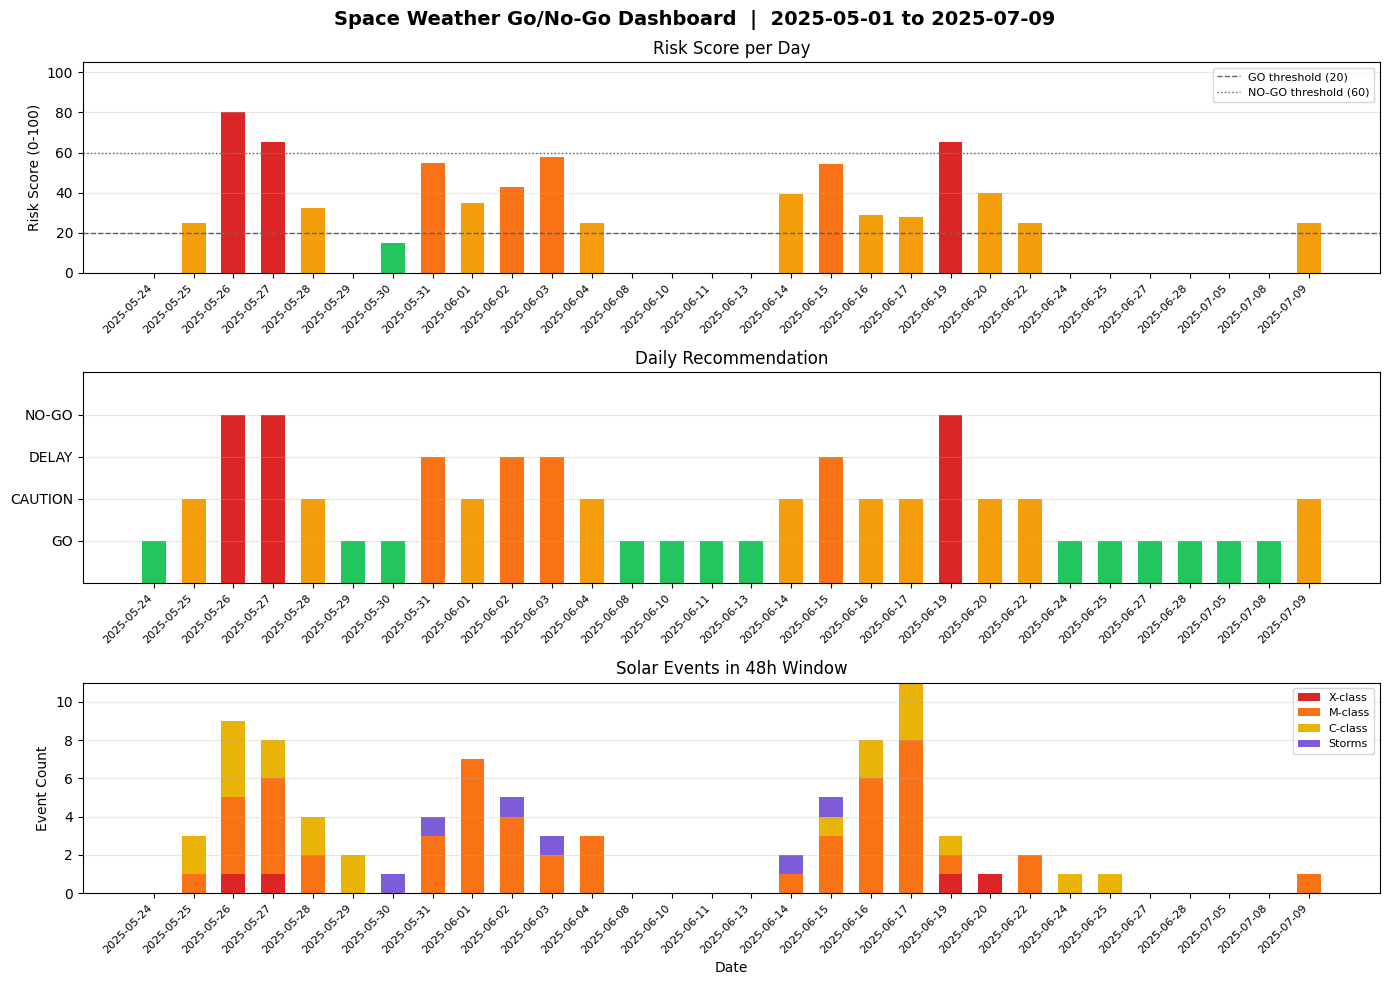

In [11]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# ── Edit these two variables to change the analysis window ─────────────────
START_DATE = '2025-05-01'
END_DATE   = '2025-07-09'
# ───────────────────────────────────────────────────────────────────

# Load saved data package
pkg = joblib.load('models/space_weather_data.pkl')
dash_df = pd.DataFrame(pkg['risk_features'])
dash_df['date'] = pd.to_datetime(dash_df['date'])

# Filter to selected window
window_df = dash_df[
    (dash_df['date'] >= pd.Timestamp(START_DATE)) &
    (dash_df['date'] <= pd.Timestamp(END_DATE))
].reset_index(drop=True)

# Compute window summary
rec_map        = {'LOW': 'GO', 'MODERATE': 'CAUTION', 'HIGH': 'DELAY', 'EXTREME': 'NO-GO'}
dominant_level = window_df['risk_level'].mode()[0] if len(window_df) else 'LOW'
max_idx        = window_df['risk_score'].idxmax()  if len(window_df) else 0
window_summary = {
    'total_days':             len(window_df),
    'avg_risk_score':         round(window_df['risk_score'].mean(), 2) if len(window_df) else 0,
    'go_days':                int((window_df['risk_level'] == 'LOW').sum()),
    'caution_days':           int((window_df['risk_level'] == 'MODERATE').sum()),
    'delay_days':             int((window_df['risk_level'] == 'HIGH').sum()),
    'nogo_days':              int((window_df['risk_level'] == 'EXTREME').sum()),
    'overall_recommendation': rec_map[dominant_level],
    'max_risk_score':         float(window_df['risk_score'].max()) if len(window_df) else 0,
    'max_risk_date':          str(window_df.loc[max_idx, 'date'])[:10] if len(window_df) else 'N/A',
}

# Print text summary
print(f"=== Go/No-Go Analysis: {START_DATE} to {END_DATE} ===")
print(f"Overall Recommendation : {window_summary['overall_recommendation']}")
print(f"Days analysed          : {window_summary['total_days']}")
print(f"Avg risk score         : {window_summary['avg_risk_score']:.2f} / 100")
print(f"GO days                : {window_summary['go_days']}")
print(f"CAUTION days           : {window_summary['caution_days']}")
print(f"DELAY days             : {window_summary['delay_days']}")
print(f"NO-GO days             : {window_summary['nogo_days']}")
print(f"Highest risk date      : {window_summary['max_risk_date']}  (score {window_summary['max_risk_score']:.1f})")

if len(window_df) == 0:
    print('\nNo data in selected window.')
else:
    color_map  = {'LOW': '#22c55e', 'MODERATE': '#f59e0b', 'HIGH': '#f97316', 'EXTREME': '#dc2626'}
    bar_colors = window_df['risk_level'].map(color_map).tolist()
    dates      = window_df['date'].dt.strftime('%Y-%m-%d').tolist()

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(
        f'Space Weather Go/No-Go Dashboard  |  {START_DATE} to {END_DATE}',
        fontsize=14, fontweight='bold'
    )

    # Subplot 1: Risk Score per Day
    ax1 = axes[0]
    ax1.bar(dates, window_df['risk_score'], color=bar_colors, width=0.6)
    ax1.axhline(20, color='#57606a', linestyle='--', linewidth=1, label='GO threshold (20)')
    ax1.axhline(60, color='#57606a', linestyle=':',  linewidth=1, label='NO-GO threshold (60)')
    ax1.set_title('Risk Score per Day')
    ax1.set_ylabel('Risk Score (0-100)')
    ax1.set_ylim(0, 105)
    ax1.set_xticks(range(len(dates)))
    ax1.set_xticklabels(dates, rotation=45, ha='right', fontsize=8)
    ax1.legend(fontsize=8)
    ax1.yaxis.grid(True, alpha=0.3)

    # Subplot 2: Daily Recommendation
    ax2 = axes[1]
    level_num = window_df['risk_level'].map({'LOW': 1, 'MODERATE': 2, 'HIGH': 3, 'EXTREME': 4}).tolist()
    ax2.bar(dates, level_num, color=bar_colors, width=0.6)
    ax2.set_yticks([1, 2, 3, 4])
    ax2.set_yticklabels(['GO', 'CAUTION', 'DELAY', 'NO-GO'])
    ax2.set_title('Daily Recommendation')
    ax2.set_ylim(0, 5)
    ax2.set_xticks(range(len(dates)))
    ax2.set_xticklabels(dates, rotation=45, ha='right', fontsize=8)
    ax2.yaxis.grid(True, alpha=0.3)

    # Subplot 3: Solar Events in 48h Window (stacked bars)
    ax3 = axes[2]
    xc = window_df['xclass_flare_count']
    mc = window_df['mclass_flare_count']
    cc = window_df['cclass_flare_count']
    sc = window_df['storm_count']
    ax3.bar(dates, xc,           color='#dc2626', width=0.6, label='X-class')
    ax3.bar(dates, mc,           color='#f97316', width=0.6, label='M-class', bottom=xc)
    ax3.bar(dates, cc,           color='#eab308', width=0.6, label='C-class', bottom=xc + mc)
    ax3.bar(dates, sc,           color='#7c5cd8', width=0.6, label='Storms',  bottom=xc + mc + cc)
    ax3.set_title('Solar Events in 48h Window')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Event Count')
    ax3.set_xticks(range(len(dates)))
    ax3.set_xticklabels(dates, rotation=45, ha='right', fontsize=8)
    ax3.legend(fontsize=8)
    ax3.yaxis.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()